In [30]:
import pyabf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import sem
import os, re
import seaborn as sns
import re
import scipy.stats as stats
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.formula.api as smf


%matplotlib widget

In [31]:
figDataSaveDir = r"C:\code\miniscope-analysis-mek\InterneuronInhibNAc\InterneuronInhibNAc\figs\paper_figs\fig_data"

### evoked epscs

In [32]:
def analyze_epsc(abf_path):
    abf = pyabf.ABF(abf_path)
    stim_time = 1.3125  # s
    baseline_start, baseline_end = 1.2, 1.3
    epsc_start, epsc_end = 1.313, 1.333

    results = []
    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep)
        t, y = abf.sweepX, abf.sweepY
        baseline = np.mean(y[(t >= baseline_start) & (t <= baseline_end)]) 
        #print(len(y[(t >= baseline_start) & (t <= baseline_end)])) #sanity check to see # of samples
        y_baselined = y - baseline
        epsc_segment = y_baselined[(t >= epsc_start) & (t <= epsc_end)]
        epsc_time = t[(t >= epsc_start) & (t <= epsc_end)]
        results.append({
            "Sweep": sweep,
            "Baseline": baseline,
            "Peak_EPSC": np.min(epsc_segment),
            "EPSC_Area": np.trapz(epsc_segment, epsc_time)
        })
    return pd.DataFrame(results)


def analyze_access_resistance(abf_path,
                                  pulse_start=5.3125,
                                  pulse_end=5.4125,
                                  step_mV=10.0,
                                  plot_example=False):
        abf = pyabf.ABF(abf_path)
        Ra_values = []
    
        # choose which sweep to plot for visualization
        plot_sweep_idx = 0  # first sweep, but you can change
    
        for sweep in range(abf.sweepCount):
            abf.setSweep(sweep)
            t, y = abf.sweepX, abf.sweepY
    
            # get data points within the pulse window
            pulse_mask = (t >= pulse_start) & (t <= pulse_end)
            t_pulse = t[pulse_mask]
            y_pulse_raw = y[pulse_mask]
            
            # compute baseline current from region just before the pulse
            baseline_mask = (t >= (pulse_start - 0.102)) & (t <= (pulse_start - 0.002))
            baseline_current = np.mean(y[baseline_mask])
            
            # subtract baseline
            y_pulse = y_pulse_raw - baseline_current
    
            # instantaneous current (peak negative deflection) - initial transient
            I0_idx = np.argmin(y_pulse)
            I0_val = y_pulse[I0_idx]
    
            # compute Ra using only the initial transient (I0 relative to baseline)
            # Ra = ΔV / ΔI, where ΔI is the initial current deflection from baseline (0)
            Ra_MOhm = step_mV / (abs(I0_val) * 1e-3)  # convert pA to nA, use abs for magnitude
            Ra_values.append(Ra_MOhm)
    
            # optional plot
            if plot_example and sweep == plot_sweep_idx:
                # get baseline region points (raw, before subtraction)
                t_base = t[baseline_mask]
                y_base_raw = y[baseline_mask]
                # baseline-corrected baseline (should hover near 0)
                y_base = y_base_raw - baseline_current
    
                plt.figure(figsize=(8,4))
                # plot baseline region first
                plt.plot(t_base, y_base, color="gray", label="Baseline region")
                # plot pulse region
                plt.plot(t_pulse, y_pulse, color="blue", label="Pulse region")
    
                # annotate I0 on pulse region
                plt.axvline(t_pulse[I0_idx], color="red", linestyle="--", label="I₀ peak (transient)")
                plt.axhline(I0_val, color="red", linestyle=":", alpha=0.7)
                plt.axhline(0, color="black", linestyle="-", alpha=0.3, label="Baseline (0)")
    
                # shade baseline region
                plt.axvspan(t_base[0], t_base[-1], color="gray", alpha=0.2)
    
                plt.xlabel("Time (s)")
                plt.ylabel("Current (pA, baseline-corrected)")
                plt.title(f"Sweep {sweep}: Rseries = {Ra_MOhm:.2f} MΩ (initial transient only)")
                plt.legend()
                plt.tight_layout()
                plt.show()
    
        return np.array(Ra_values)

def get_avg_trace(abf_path, start=1.2, end=1.4, baseline_start=1.2, baseline_end=1.3):
    abf = pyabf.ABF(abf_path)
    traces = []
    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep)
        t, y = abf.sweepX, abf.sweepY
        baseline = np.mean(y[(t >= baseline_start) & (t <= baseline_end)])
        traces.append(y - baseline)
    traces = np.array(traces)
    avg_trace = np.mean(traces, axis=0)
    return t, avg_trace


def analyze_multiple_abf_files(abf_paths):
    all_dfs = []
    sweep_offset = 0
    for abf_path in abf_paths:
        df = analyze_epsc(abf_path)
        df["Sweep"] += sweep_offset
        all_dfs.append(df)
        sweep_offset += len(df)
    full_df = pd.concat(all_dfs, ignore_index=True)
    return full_df

def analyze_cell(cell_folder):
    # Find metadata file
    metadata_files = [f for f in os.listdir(cell_folder) if f.endswith("_metadata.csv")]
    if len(metadata_files) != 1:
        raise ValueError(f"Expected 1 metadata file in {cell_folder}, found {len(metadata_files)}")

    metadata_file = metadata_files[0]
    metadata_path = os.path.join(cell_folder, metadata_file)

    # Infer cell type from filename
    if "_fsi_" in metadata_file.lower():
        cell_type = "FSI"
    elif "_msn_" in metadata_file.lower():
        cell_type = "MSN"
    else:
        raise ValueError(f"Cell type not found in metadata filename: {metadata_file}")

    meta = pd.read_csv(metadata_path)
    
    # Extract file lists
    baseline_file = meta[meta["phase"] == "baseline"]["file"].values[0]
    drug_files = meta[meta["phase"] == "drug"]["file"].values

    baseline_path = os.path.join(cell_folder, baseline_file)
    drug_paths = [os.path.join(cell_folder, f) for f in drug_files]

    # Analyze EPSC data (raw values only, no normalization yet)
    baseline_df = analyze_epsc(baseline_path)
    drug_df = analyze_multiple_abf_files(drug_paths)

    bin_size = 1/3  # each bin = 3 sweeps = 1 min
    
    # Assign baseline bins: go from -4 to 0 (5 total)
    baseline_df["Time_min"] = np.arange(len(baseline_df)) // 3 - (len(baseline_df) // 3) + 1
    
    # Assign drug bins: start at 1 and increment
    drug_df["Time_min"] = np.arange(len(drug_df)) // 3 + 1




    # Merge raw data
    full_df = pd.concat([baseline_df, drug_df], ignore_index=True)
    full_df["Sweep"] = range(len(full_df))
    full_df["Bin"] = full_df["Sweep"] // 3  # 1-min bin = 3 sweeps

    # *** NEW APPROACH: Average raw values first, then normalize ***
    
    # Bin/average the raw EPSC values
    binned_df = (
        full_df
        .groupby("Bin")
        .agg(
            Time_min=("Time_min", "mean"),
            Peak_EPSC_Raw_Mean=("Peak_EPSC", "mean"),
            Peak_EPSC_Raw_SEM=("Peak_EPSC", sem),
            EPSC_Area_Raw_Mean=("EPSC_Area", "mean"),
            EPSC_Area_Raw_SEM=("EPSC_Area", sem)
        )
        .reset_index()
    )
    # Now binned_df has Bin as a column
    
    # Calculate baseline means from the binned baseline data
    baseline_bins = binned_df[binned_df["Time_min"] < 0]
    baseline_peak_mean = baseline_bins["Peak_EPSC_Raw_Mean"].mean()
    baseline_area_mean = baseline_bins["EPSC_Area_Raw_Mean"].mean()
    
    # Now normalize the binned averages
    binned_df["Peak_EPSC_Norm_Mean"] = binned_df["Peak_EPSC_Raw_Mean"] / baseline_peak_mean
    binned_df["EPSC_Area_Norm_Mean"] = binned_df["EPSC_Area_Raw_Mean"] / baseline_area_mean
    
    # For SEM, normalize by the same baseline means
    binned_df["Peak_EPSC_Norm_SEM"] = binned_df["Peak_EPSC_Raw_SEM"] / abs(baseline_peak_mean)
    binned_df["EPSC_Area_Norm_SEM"] = binned_df["EPSC_Area_Raw_SEM"] / abs(baseline_area_mean)

    
    # ---- Access resistance (Rseries) analysis ----
    baseline_rseries = analyze_access_resistance(baseline_path)
    drug_rseries_all = [analyze_access_resistance(p) for p in drug_paths]
    drug_rseries = np.concatenate(drug_rseries_all) if len(drug_rseries_all) else np.array([])
    
    all_rseries = np.concatenate([baseline_rseries, drug_rseries])
    
    if len(all_rseries) > 0:
        # Build time vector matching EPSC time logic
        time_baseline = (np.arange(len(baseline_rseries)) - len(baseline_rseries)) * (1/3)
        time_drug = np.arange(len(drug_rseries)) * (1/3)
        time_all = np.concatenate([time_baseline, time_drug])
    
        # Build DataFrame for Rseries
        rseries_df = pd.DataFrame({
            "Sweep": np.arange(len(all_rseries)),
            "Time_min": time_all,
            "Rseries_MOhm": all_rseries
        })
        rseries_df["Bin"] = rseries_df["Sweep"] // 3
    
        rseries_binned = (
            rseries_df.groupby("Bin")
                      .agg(Time_min=("Time_min", "mean"),
                           Rseries_Mean=("Rseries_MOhm", "mean"),
                           Rseries_SEM=("Rseries_MOhm", sem))
                      .reset_index()   # <-- NOT drop=True
        )

    
        # Calculate baseline mean for Rseries
        baseline_bins_rseries = rseries_binned[rseries_binned["Time_min"] < 0]
        baseline_rseries_mean = baseline_bins_rseries["Rseries_Mean"].mean()
        
        # Add normalized Rseries (% change from baseline)
        rseries_binned["Rseries_Norm_Mean"] = rseries_binned["Rseries_Mean"] / baseline_rseries_mean
        rseries_binned["Rseries_Norm_SEM"] = rseries_binned["Rseries_SEM"] / baseline_rseries_mean
    
        # Merge Rseries data with EPSC data
        # Both DataFrames should have "Bin" as a column now
        binned_df = binned_df.merge(
            rseries_binned[["Bin", "Rseries_Mean", "Rseries_SEM", "Rseries_Norm_Mean", "Rseries_Norm_SEM"]], 
            on="Bin", 
            how="left"
        )

        #print(binned_df)
    
        # QC check for Rseries deviation >30%
        deviations = (rseries_binned["Rseries_Mean"] - baseline_rseries_mean) / baseline_rseries_mean
        exceed_idx = np.where(np.abs(deviations) > 0.30)[0]
        if len(exceed_idx) > 0:
            first_idx = exceed_idx[0]
            first_time = rseries_binned.loc[first_idx, "Time_min"]
            first_value = rseries_binned.loc[first_idx, "Rseries_Mean"]
            
    else:
        print(f"[{cell_type}] No valid Rseries values found.")
        # Add empty Rseries columns
        binned_df["Rseries_Mean"] = np.nan
        binned_df["Rseries_SEM"] = np.nan
        binned_df["Rseries_Norm_Mean"] = np.nan
        binned_df["Rseries_Norm_SEM"] = np.nan

    # Clean up - drop raw columns if you don't need them
    binned_df = binned_df.drop(columns=["Peak_EPSC_Raw_Mean", "Peak_EPSC_Raw_SEM", 
                                       "EPSC_Area_Raw_Mean", "EPSC_Area_Raw_SEM"])
    
    binned_df["Cell_Type"] = cell_type

        
    return binned_df


def batch_analyze_all_cells(parent_folder):
    all_cells = [f for f in os.listdir(parent_folder) if os.path.isdir(os.path.join(parent_folder, f))]
    all_results = {}

    for cell in all_cells:
        print(f"Analyzing: {cell}")
        cell_folder = os.path.join(parent_folder, cell)
        try:
            binned = analyze_cell(cell_folder)
            all_results[cell] = binned
        except Exception as e:
            print(f"Failed on {cell}: {e}")
    
    return all_results


In [33]:
def plot_grouped_epsc_traces(
    results_dict,
    parent_folder,
    include_cells=None,
    qc_threshold=0.30,
    output_dir=None,
    example_cell_names=None,  # NEW: dict like {"MSN": "cell5_msn", "FSI": "cell2_fsi"}
    stim_zero_window=(1.3125, 1.3145),  
    plot_window_ms=(10, 40)         
):

    filtered_results = {}
    excluded_bins = {}

    # --- QC filtering ---
    for cell, df in results_dict.items():
        df_temp = df.copy()
        if "Rseries_Norm_Mean" in df_temp.columns:
            good_mask = np.abs(df_temp["Rseries_Norm_Mean"] - 1) <= qc_threshold
            bad_bins = df_temp.loc[~good_mask, "Time_min"].tolist()
            df_temp = df_temp.loc[good_mask].reset_index(drop=True)
            if not df_temp.empty:
                filtered_results[cell] = df_temp
            if bad_bins:
                excluded_bins[cell] = bad_bins
        else:
            excluded_bins[cell] = "No Rs data"

        def extract_cell_number(cell_name):
            match = re.match(r"cell(\d+)_", cell_name)
            return int(match.group(1)) if match else None

        if include_cells is not None:
            filtered_results = {
                cell: df for cell, df in filtered_results.items()
                if extract_cell_number(cell) in include_cells
            }

    print(f"Using {len(filtered_results)} of {len(results_dict)} cells (after per-bin QC)")

    all_fsi = [df for cell, df in filtered_results.items() if df["Cell_Type"].iloc[0].strip().upper() == "FSI"]
    all_msn = [df for cell, df in filtered_results.items() if df["Cell_Type"].iloc[0].strip().upper() == "MSN"]

    fsi_color = "#4B2E8D"  # purple  
    msn_color = "#07AC4B"  # green

    def compute_group_stats(dfs):
        if not dfs:
            return None
        concat = pd.concat(dfs, ignore_index=True)
        concat = concat[concat["Time_min"] <= 30]
        stats = concat.groupby("Time_min")["Peak_EPSC_Norm_Mean"].agg(['mean', 'std', 'count']).reset_index()
        stats.rename(columns={'mean': 'Peak_EPSC_Norm_Mean',
                              'std': 'Peak_EPSC_Norm_STD',
                              'count': 'N'}, inplace=True)
        stats["Peak_EPSC_Norm_SEM"] = stats["Peak_EPSC_Norm_STD"] / np.sqrt(stats["N"])
        return stats

    fsi_group = compute_group_stats(all_fsi)
    msn_group = compute_group_stats(all_msn)

    # --- FIGURE 1: population time course ---
    fig, ax1= plt.subplots(figsize=(10, 4))

    def safe_plot(ax, df, label, color):
        if df is not None and len(df) > 0:
            df_clean = df.dropna(subset=["Peak_EPSC_Norm_Mean"])
            if not df_clean.empty:
                yerr = df_clean["Peak_EPSC_Norm_SEM"]
                ax.errorbar(df_clean["Time_min"], df_clean["Peak_EPSC_Norm_Mean"],
                            yerr=yerr, fmt='o-', capsize=4, markersize=7,
                            label=label, color=color, markeredgewidth=0)

    safe_plot(ax1, fsi_group, "FSI", fsi_color)
    safe_plot(ax1, msn_group, "MSN", msn_color)

    ax1.axhline(1, linestyle='--', color='gray')
    ax1.axvline(0.5, linestyle='--', color='black', label='IEM-1460 Onset')
    ax1.set_ylabel("Normalized EPSC Peak")
    ax1.set_title("EPSC Peak Amplitude (Mean ± SEM, QC-passed bins)")
    ax1.legend()
    ax1.set_ylim(0.25, 1.75)
    ax1.set_xlim(-5, 31)

    plt.tight_layout()

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        fig.savefig(os.path.join(output_dir, "eEPSC_plot.svg"))
        fig.savefig(os.path.join(output_dir, "eEPSC_plot.png"), dpi=300)

    def get_avg_trace_from_files(file_list, start, end, baseline_start, baseline_end, zero_window):
        traces = []
        for abf_path in file_list:
            abf = pyabf.ABF(abf_path)
            for sweep in range(abf.sweepCount):
                abf.setSweep(sweep)
                t, y = abf.sweepX, abf.sweepY

                # baseline subtraction
                baseline = np.mean(y[(t >= baseline_start) & (t <= baseline_end)])

                # zero-out stim artifact
                stim_mask = (t >= zero_window[0]) & (t <= zero_window[1])
                y[stim_mask] = np.nan

                traces.append(y - baseline)
        traces = np.array(traces)
        avg_trace = np.mean(traces, axis=0)
        return t, avg_trace

    # Select example cells
    example_files = {}
    if example_cell_names:
        # Use provided cells
        for cell_type, cell_name in example_cell_names.items():
            meta_file = [f for f in os.listdir(os.path.join(parent_folder, cell_name)) if f.endswith("_metadata.csv")][0]
            meta_path = os.path.join(parent_folder, cell_name, meta_file)
            meta = pd.read_csv(meta_path)
            baseline_file = meta[meta["phase"] == "baseline"]["file"].values[0]
            drug_files = meta[meta["phase"] == "drug"]["file"].values
            baseline_path = os.path.join(parent_folder, cell_name, baseline_file)
            drug_paths = [os.path.join(parent_folder, cell_name, f) for f in drug_files]
            example_files[cell_type.upper()] = {"baseline": baseline_path, "drug": drug_paths}

        fig2, axs = plt.subplots(2, 1, figsize=(4, 4), sharex=True)
    
        for ax, cell_type, color in zip(axs, ["MSN", "FSI"], [msn_color, fsi_color]):
            if cell_type in example_files:
                # First 5 min = baseline
                t_base, avg_base = get_avg_trace_from_files(
                    [example_files[cell_type]["baseline"]],
                    start=1.2, end=1.4,
                    baseline_start=1.2, baseline_end=1.3,
                    zero_window=stim_zero_window
                )
    
                # Last 5 min = last drug file
                t_drug, avg_drug = get_avg_trace_from_files(
                    [example_files[cell_type]["drug"][-1]],
                    start=1.2, end=1.4,
                    baseline_start=1.2, baseline_end=1.3,
                    zero_window=stim_zero_window
                )
    
                # Convert to ms from stim
                t_ms = (t_base - 1.3) * 1000
                plot_mask = (t_ms >= plot_window_ms[0]) & (t_ms <= plot_window_ms[1])
    
                ax.plot(t_ms[plot_mask], avg_base[plot_mask], color=color, lw=1.5, label="Baseline")
                ax.plot(t_ms[plot_mask], avg_drug[plot_mask], color=color, lw=1.5, ls="--", label="Drug")
                ax.set_title(cell_type)
                ax.axis('off')
    
    
        plt.tight_layout()

    if output_dir:
        fig2.savefig(os.path.join(output_dir, "eEPSC_example_traces.svg"))
        fig2.savefig(os.path.join(output_dir, "eEPSC_example_traces.png"), dpi=300)

    all_data = []
    for cell, df in filtered_results.items():
        df = df.copy()
        df["Cell_ID"] = cell
        all_data.append(df)
    combined_df = pd.concat(all_data, ignore_index=True)

    if output_dir:
        cols_to_keep = ["Cell_ID", "Cell_Type", "Time_min", "Peak_EPSC_Norm_Mean", "Peak_EPSC_Norm_SEM",
                        "Rseries_Mean", "Rseries_SEM", "Rseries_Norm_Mean", "Rseries_Norm_SEM"]
        export_df = combined_df[cols_to_keep].copy()
        export_df.to_csv(os.path.join(output_dir, "eEPSC_data.csv"), index=False)


    lme_df = combined_df[["Cell_ID", "Cell_Type", "Time_min", "Peak_EPSC_Norm_Mean"]].dropna()
    lme_df["Cell_Type"] = lme_df["Cell_Type"].str.strip().str.upper().astype("category")
    model = smf.mixedlm("Peak_EPSC_Norm_Mean ~ Cell_Type * Time_min",
                        data=lme_df,
                        groups=lme_df["Cell_ID"])
    result = model.fit()

    lme_df["PostDrug"] = (lme_df["Time_min"] >= 1).astype(int)

    model2 = smf.mixedlm("Peak_EPSC_Norm_Mean ~ Cell_Type * PostDrug",
                         data=lme_df,
                         groups=lme_df["Cell_ID"])
    result2 = model2.fit()

    if output_dir:
        with open(os.path.join(output_dir, "EPSC_stats.txt"), "w") as f:
            f.write("--- Linear Mixed-Effects Model (LME) ---\n")
            f.write(result.summary().as_text())
            f.write("\n\n--- LME: Group × PostDrug interaction ---\n")
            f.write(result2.summary().as_text())

    
    def tidy_lme_with_pvals(result):
        return pd.DataFrame({
            "coef": result.params,
            "se": result.bse,
            "z": result.tvalues,
            "p": result.pvalues
        }).applymap(lambda x: f"{x:.3g}" if isinstance(x, float) else x)
    
    print("\n--- Time as continuous ---\n", tidy_lme_with_pvals(result))
    print("\n--- Pre/PostDrug ---\n", tidy_lme_with_pvals(result2))





In [34]:
results = batch_analyze_all_cells(r"E:\patching\data\CellsToAnalyze")


Analyzing: cell10_FS
Analyzing: cell11_FS
Analyzing: cell12_FS
Analyzing: cell13_FS
Analyzing: cell14_MSN
Analyzing: cell15_MSN
Analyzing: cell16_MSN
Analyzing: cell18_MSN
Analyzing: cell5_MSN
Analyzing: cell6_MSN
Analyzing: cell7_MSN
Analyzing: cell8_MSN
Analyzing: cell9_FS


Using 13 of 13 cells (after per-bin QC)

--- Time as continuous ---
                               coef       se      z         p
Intercept                    0.895   0.0771   11.6   3.6e-31
Cell_Type[T.MSN]             0.149   0.0983   1.51      0.13
Time_min                   -0.0122  0.00117  -10.4  3.37e-25
Cell_Type[T.MSN]:Time_min   0.0156  0.00154   10.1  3.32e-24
Group Var                     1.03    0.455   2.25    0.0242

--- Pre/PostDrug ---
                                coef      se        z         p
Intercept                      1.01  0.0809     12.4     2e-35
Cell_Type[T.MSN]           -0.00297   0.103  -0.0288     0.977
PostDrug                     -0.319  0.0365    -8.74  2.36e-18
Cell_Type[T.MSN]:PostDrug     0.419  0.0466     8.99  2.44e-19
Group Var                     0.944    0.42     2.25    0.0246


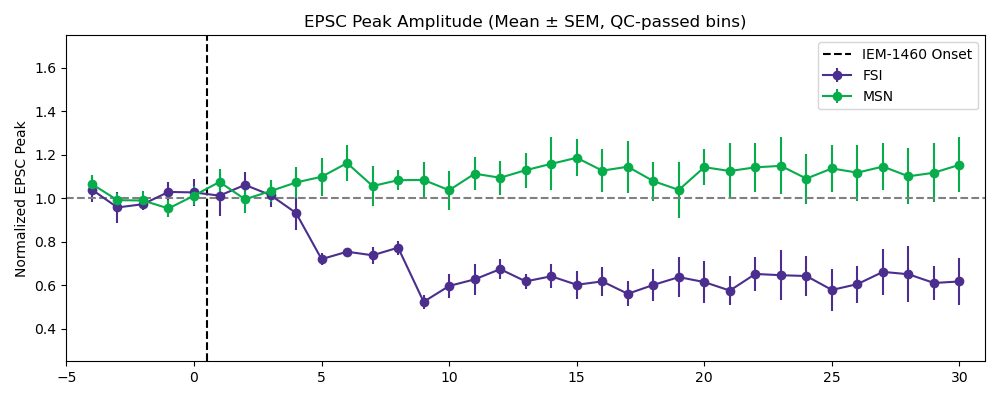

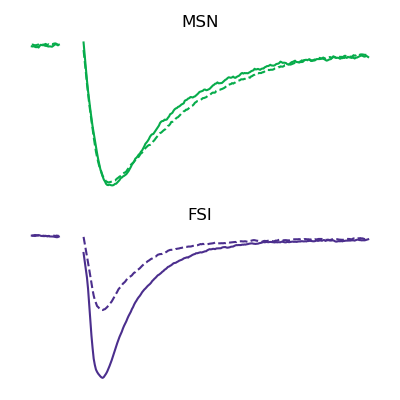

In [7]:
plot_grouped_epsc_traces(results, 
                         parent_folder = r"E:\patching\data\CellsToAnalyze",
                         output_dir = figDataSaveDir + '/patching/evoked',
                        example_cell_names={"MSN": "cell7_MSN", "FSI": "cell13_FS"}
                        )


In [16]:
def plot_25_30min_cell_averages(results_dict, save_dir, include_cells=None, qc_threshold=0.30):
    os.makedirs(save_dir, exist_ok=True)

    def extract_cell_num(name):
        m = re.search(r"cell(\d+)_", str(name), flags=re.IGNORECASE)
        return int(m.group(1)) if m else None

    # Filter per-bin Rs
    filtered_results = {}
    for cell, df in results_dict.items():
        if "Rseries_Norm_Mean" in df.columns:
            ok = np.abs(df["Rseries_Norm_Mean"] - 1) <= qc_threshold
            df = df.loc[ok]
        if not df.empty:
            filtered_results[cell] = df

    # Exact numeric include filter
    if include_cells is not None:
        keep = set(include_cells)
        filtered_results = {
            c: df for c, df in filtered_results.items()
            if extract_cell_num(c) in keep
        }

    # Compute averages
    rows = []
    for cell, df in filtered_results.items():
        sub = df[(df["Time_min"] >= 25) & (df["Time_min"] <= 30)]
        if not sub.empty:
            rows.append({
                "Cell_ID": cell,
                "Cell_Type": df["Cell_Type"].iloc[0].strip().upper(),
                "EPSC_25_30": sub["Peak_EPSC_Norm_Mean"].mean()
            })
    avg_df = pd.DataFrame(rows)
    avg_df.to_csv(os.path.join(save_dir, "eEPSC_25_30min_cell_averages.csv"), index=False)

    # Plot
    colors = {"FSI": "#4B2E8D", "MSN": "#07AC4B"}
    positions = {"FSI": 0.9, "MSN": 1.1}  # closer together

    fig, ax = plt.subplots(figsize=(4, 4))
    for ctype in ["FSI", "MSN"]:
        vals = avg_df.loc[avg_df["Cell_Type"] == ctype, "EPSC_25_30"]
        if vals.empty: 
            continue
        ax.scatter(
            np.full(len(vals), positions[ctype]),
            vals,
            color=colors[ctype],
            edgecolor='k',
            s=70,
            zorder=3
        )
        mean_val = vals.mean()
        sem_val = sem(vals) if len(vals) > 1 else 0
        ax.errorbar(
            positions[ctype],
            mean_val,
            yerr=sem_val,
            fmt='o',
            color='k',
            capsize=4,
            zorder=4
        )

    ax.set_xticks([positions["FSI"], positions["MSN"]])
    ax.set_xticklabels(["FSI", "MSN"])
    ax.set_ylabel("Normalized EPSC Peak (25–30 min)")
    ax.set_xlim(0.8, 1.2)
    ax.set_title("Per-cell EPSC averages (QC-passed)")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fig.savefig(os.path.join(save_dir, "eEPSC_25_30min_cell_averages.svg"))
    fig.savefig(os.path.join(save_dir, "eEPSC_25_30min_cell_averages.png"), dpi=300)
    plt.show()

    # simple extra CSV with value + cell type
    simple_df = avg_df[["EPSC_25_30", "Cell_Type"]].copy()
    simple_df.to_csv(os.path.join(save_dir, "eEPSC_25_30min_values_and_type.csv"), index=False)


    return avg_df

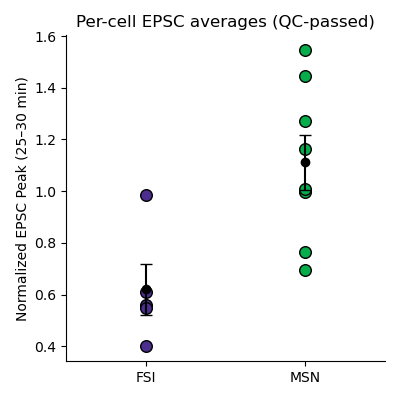

In [17]:
avg_df = plot_25_30min_cell_averages(
    results,
    figDataSaveDir + '/patching/evoked',
)

In [18]:
# Extract values
fsi_vals = avg_df.loc[avg_df.Cell_Type == "FSI", "EPSC_25_30"]
msn_vals = avg_df.loc[avg_df.Cell_Type == "MSN", "EPSC_25_30"]

# --- 1-sample t-tests vs 1 ---
t_fsi_with, p_fsi_with = stats.ttest_1samp(fsi_vals, 1)
t_msn, p_msn = stats.ttest_1samp(msn_vals, 1)

# --- Independent t-tests FSI vs MSN ---
t_cmp_with, p_cmp_with = stats.ttest_ind(fsi_vals, msn_vals, equal_var=False)

# --- Print results ---
print("FSI vs 1:     t = %.3f, p = %.4f, n = %d" % (t_fsi_with, p_fsi_with, len(fsi_vals)))
print("MSN vs 1:                    t = %.3f, p = %.4f, n = %d" % (t_msn, p_msn, len(msn_vals)))
print("FSI vs MSN:   t = %.3f, p = %.4f, n_FSI = %d, n_MSN = %d" % (t_cmp_with, p_cmp_with, len(fsi_vals), len(msn_vals)))



FSI vs 1:     t = -3.886, p = 0.0178, n = 5
MSN vs 1:                    t = 1.040, p = 0.3328, n = 8
FSI vs MSN:   t = -3.384, p = 0.0064, n_FSI = 5, n_MSN = 8


### intrinsics

In [75]:
def compute_rmp_from_rheoramp(abf_path, rest_window=(0.0, 0.5781), voltage_channel=0):
    abf = pyabf.ABF(abf_path)
    rmps = []
    for sw in range(abf.sweepCount):
        abf.setSweep(sw, channel=voltage_channel)
        t, v = abf.sweepX, abf.sweepY
        if abf.sweepUnitsY.lower() == "v":
            v = v * 1000.0
        m = (t >= rest_window[0]) & (t <= rest_window[1])
        rmps.append(float(np.mean(v[m])) if np.any(m) else np.nan)
    rmps = np.asarray(rmps, dtype=float)
    return rmps, float(np.nanmean(rmps)) if rmps.size else np.nan

# --- Helper: RMP from CI baseline (0.4–0.5 s), matches your previous behavior ---
def compute_rmp_from_ci(abf_path, rest_window=(0.4, 0.5), voltage_channel=0):
    abf = pyabf.ABF(abf_path)
    rmps = []
    for sw in range(abf.sweepCount):
        abf.setSweep(sw, channel=voltage_channel)
        t, v = abf.sweepX, abf.sweepY
        if abf.sweepUnitsY.lower() == "v":
            v = v * 1000.0
        m = (t >= rest_window[0]) & (t <= rest_window[1])
        rmps.append(float(np.mean(v[m])) if np.any(m) else np.nan)
    rmps = np.asarray(rmps, dtype=float)
    return rmps, float(np.nanmean(rmps)) if rmps.size else np.nan

# --- CI analysis (NO RMP inside) ---
def analyze_fi_curve_ci(
    abf_path,
    stim_start=0.5468,
    stim_end=0.6468,
    start_current=-200,
    delta_current=25,
    voltage_channel=0
):
    abf = pyabf.ABF(abf_path)
    rows = []
    for sweep in range(abf.sweepCount):
        abf.setSweep(sweep, channel=voltage_channel)
        t, v = abf.sweepX, abf.sweepY
        if abf.sweepUnitsY.lower() == "v":
            v = v * 1000.0

        I = start_current + delta_current * sweep

        crossings_all = np.where((v[:-1] < 0) & (v[1:] >= 0))[0]
        mask = (t[crossings_all] >= stim_start) & (t[crossings_all] <= stim_end)
        crossings = crossings_all[mask]

        n_spikes = int(len(crossings))
        dur = float(stim_end - stim_start)
        fr = n_spikes / dur if dur > 0 else 0.0

        halfwidths = []
        for idx in crossings:
            search_win = int(0.01 * abf.dataRate)
            end_idx = min(idx + search_win, len(v))
            peak_idx = idx + int(np.argmax(v[idx:end_idx]))
            peak_v = float(v[peak_idx])
            baseline_v = float(v[idx])
            half_amp = baseline_v + 0.5 * (peak_v - baseline_v)
            left = np.where(v[:peak_idx] < half_amp)[0]
            right = np.where(v[peak_idx:] < half_amp)[0]
            if len(left) and len(right):
                t1 = float(t[left[-1]])
                t2 = float(t[peak_idx + right[0]])
                halfwidths.append((t2 - t1) * 1000.0)

        hw_mean = float(np.mean(halfwidths)) if halfwidths else np.nan

        rows.append({
            "Sweep": sweep,
            "Current_pA": I,
            "SpikeCount": n_spikes,
            "FiringRate_Hz": fr,
            "AP_HalfWidth_ms": hw_mean
        })

    df = pd.DataFrame(rows)
    depol = df[df["Current_pA"] > 0]
    summary = {
        "MaxFR_Hz": float(depol["FiringRate_Hz"].max()) if not depol.empty else 0.0,
        "AP_HalfWidth_ms": float(depol["AP_HalfWidth_ms"].mean()) if not depol.empty else np.nan
    }
    return df, summary

# --- Batch: prefer rheoramp RMP; fallback to CI baseline if rheoramp missing ---
def batch_analyze_all_cells_fi_ci(parent_folder):
    """
    Uses rheoramp (phase=='rheoramp') RMP from 0–0.5781 s if present.
    If missing, falls back to CI baseline RMP from 0.4–0.5 s (previous behavior).
    """
    all_cells = [f for f in os.listdir(parent_folder) if os.path.isdir(os.path.join(parent_folder, f))]
    all_sweeps, all_summaries = [], []

    for cell in all_cells:
        print(f"Analyzing FI (CI, RMP: rheoramp→fallback CI): {cell}")
        cell_dir = os.path.join(parent_folder, cell)
        try:
            metas = [f for f in os.listdir(cell_dir) if f.endswith("_metadata.csv")]
            if len(metas) != 1:
                print(f"Skipping {cell}: metadata missing or not unique")
                continue

            meta = pd.read_csv(os.path.join(cell_dir, metas[0]))
            if "phase" not in meta.columns or "file" not in meta.columns:
                print(f"Skipping {cell}: bad metadata")
                continue
            meta["phase_norm"] = meta["phase"].astype(str).str.strip().str.lower()

            # Find rheoramp file
            rmp_mean = np.nan
            rheo_files = meta.loc[meta["phase_norm"] == "rheoramp", "file"].astype(str).tolist()
            if rheo_files:
                rheo_path = os.path.join(cell_dir, rheo_files[0])
                if os.path.exists(rheo_path):
                    _, rmp_mean = compute_rmp_from_rheoramp(rheo_path, rest_window=(0.0, 0.5781))
                else:
                    print(f"{cell}: rheoramp not found at {rheo_path}; will try CI baseline fallback")

            # CI files
            ci_files = meta.loc[meta["phase_norm"] == "ci", "file"].astype(str).tolist()
            if not ci_files:
                print(f"Skipping {cell}: no CI files")
                continue

            cell_frames = []
            for ci_file in ci_files:
                ci_path = os.path.join(cell_dir, ci_file)
                if not os.path.exists(ci_path):
                    print(f"Missing {ci_path}")
                    continue

                df_sw, summ = analyze_fi_curve_ci(ci_path)
                df_sw["File"] = ci_file
                df_sw["Cell_ID"] = cell

                # If no rheoramp RMP yet, compute from this CI file (fallback to 0.4–0.5 s)
                if np.isnan(rmp_mean):
                    _, rmp_mean = compute_rmp_from_ci(ci_path, rest_window=(0.4, 0.5))

                # attach the (single) per-cell RMP to all sweeps
                df_sw["RestingVm_mV"] = rmp_mean
                cell_frames.append(df_sw)

            if cell_frames:
                df_all = pd.concat(cell_frames, ignore_index=True)
                all_sweeps.append(df_all)
                all_summaries.append({
                    "Cell_ID": cell,
                    "RestingVm_mean": rmp_mean,
                    "MaxFR_Hz": float(df_all[df_all["Current_pA"] > 0]["FiringRate_Hz"].max()),
                    "AP_HalfWidth_ms": float(df_all["AP_HalfWidth_ms"].mean(skipna=True))
                })

        except Exception as e:
            print(f"Failed on {cell}: {e}")

    sweeps = pd.concat(all_sweeps, ignore_index=True) if all_sweeps else pd.DataFrame()
    summaries = pd.DataFrame(all_summaries) if all_summaries else pd.DataFrame()
    return sweeps, summaries


In [76]:
parent_folder = r"E:\patching\data\CellsToAnalyze"
all_sweeps, cell_summaries = batch_analyze_all_cells_fi_ci(parent_folder)

all_sweeps.to_csv(os.path.join(parent_folder, "fi_sweep_data.csv"), index=False)
cell_summaries.to_csv(os.path.join(parent_folder, "fi_cell_summary.csv"), index=False)


Analyzing FI (CI, RMP: rheoramp→fallback CI): cell10_FS
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell11_FS
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell12_FS
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell13_FS
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell14_MSN
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell15_MSN
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell16_MSN
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell18_MSN
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell5_MSN
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell6_MSN
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell7_MSN
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell8_MSN
Analyzing FI (CI, RMP: rheoramp→fallback CI): cell9_FS


In [77]:
def plot_fi_curves_from_df(all_sweeps, output_dir=None):
    """
    Generates:
    1. Individual F–I curves for each cell
    2. Mean ± SEM F–I curves separated for MSNs vs FSIs
    Auto-detects Cell_Type from Cell_ID if missing.
    """

    colors = {
        'MSN': '#07AC4B',  # Green
        'FSI': '#4B2E8D'   # Purple
    }

    required_cols = {"Cell_ID", "Current_pA", "FiringRate_Hz"}
    if not required_cols.issubset(all_sweeps.columns):
        raise ValueError(f"Missing required columns: {required_cols}")

        print("'Cell_Type' column missing; inferring from 'Cell_ID'.")
        
    def detect_cell_type(x):
        name = str(x).upper()
        if "_FS" in name:
            detected = "FSI"
        elif "_MSN" in name:
            detected = "MSN"
        else:
            detected = "Unknown"
        return detected
    
    all_sweeps["Cell_Type"] = all_sweeps["Cell_ID"].apply(detect_cell_type)

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    # --- 1) Plot individual curves ---
    for cell_id, group in all_sweeps.groupby("Cell_ID"):
        plt.figure(figsize=(6, 4))
        cell_type = group["Cell_Type"].iloc[0]
        color = colors.get(cell_type, 'gray')
        plt.plot(group["Current_pA"], group["FiringRate_Hz"], 'o-', color=color, label=f'{cell_type} Sweeps')

        plt.title(f"F-I Curve: {cell_id}")
        plt.xlabel("Injected Current (pA)")
        plt.ylabel("Firing Rate (Hz)")
        plt.ylim(bottom=0)
        plt.grid(False)
        plt.legend()
        plt.tight_layout()

        if output_dir:
            save_path = os.path.join(output_dir, f"{cell_id}_FI_curve.png")
            plt.savefig(save_path, dpi=300)
            plt.close()

    # --- 2) Population mean ± SEM ---
    mean_sem_data = (
        all_sweeps.groupby(["Cell_Type", "Current_pA"])
        .agg(
            N=("FiringRate_Hz", "size"),
            mean_rate=("FiringRate_Hz", "mean"),
            sem_rate=("FiringRate_Hz", lambda x: x.std(ddof=1)/np.sqrt(len(x)))
        )
        .reset_index()
    )

    # NEW: save population mean ± SEM to CSV
    if output_dir:
        csv_path = os.path.join(output_dir, "Population_FI_mean_sem_by_type.csv")
        mean_sem_data.to_csv(csv_path, index=False)

    plt.figure(figsize=(7, 5))
    colors = {'MSN': '#07AC4B', 'FSI': '#4B2E8D'}

    for cell_type, group in mean_sem_data.groupby("Cell_Type"):
        plt.errorbar(group["Current_pA"], group["mean_rate"], 
                     yerr=group["sem_rate"], 
                     fmt='o-', label=cell_type, 
                     color=colors.get(cell_type, 'gray'), capsize=4)

    plt.title("Population F-I Curves")
    plt.xlabel("Injected Current (pA)")
    plt.ylabel("Firing Rate (Hz)")
    plt.ylim(bottom=0)
    plt.grid(False)
    plt.legend(title="Cell Type")
    plt.tight_layout()

    if output_dir:
        stem = os.path.join(output_dir, "Population_FI_curves")
        plt.savefig(stem + ".png", dpi=300)
        plt.savefig(stem + ".svg")
    else:
        plt.show()

    print("F–I curves generated (individual and population-level)")



F–I curves generated (individual and population-level)


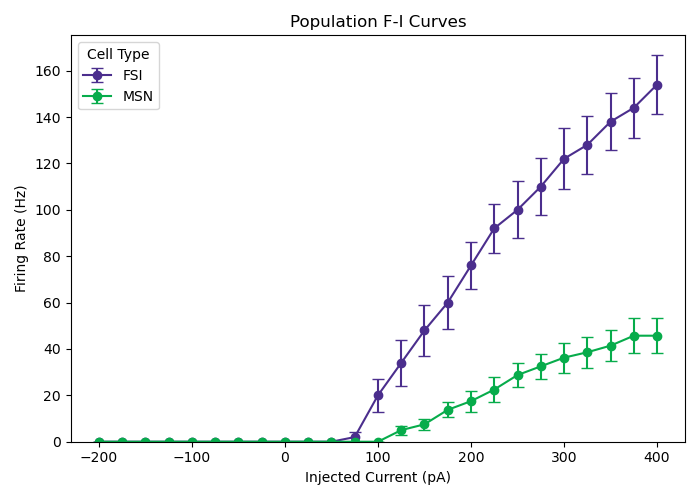

In [78]:
plot_fi_curves_from_df(all_sweeps, output_dir=figDataSaveDir + '/patching/FI_Curves')


In [56]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# Copy the data
df = all_sweeps.copy()

# Ensure Cell_Type exists
def detect_cell_type(x):
    s = str(x).upper()
    if "_FS" in s:
        return "FSI"
    elif "_MSN" in s:
        return "MSN"
    else:
        return "UNKNOWN"

if "Cell_Type" not in df.columns:
    df["Cell_Type"] = df["Cell_ID"].apply(detect_cell_type)

df["Cell_Type"] = df["Cell_Type"].str.upper().astype("category")

# Drop UNKNOWN cell types
df = df[df["Cell_Type"] != "UNKNOWN"]

# Remove inf/nan
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["Current_pA", "FiringRate_Hz"])

# Fit mixed LME
model = smf.mixedlm(
    "FiringRate_Hz ~ Cell_Type * Current_pA",
    data=df,
    groups=df["Cell_ID"]
)
result = model.fit()

# Function to make tidy table
def tidy_lme_with_pvals(result):
    return pd.DataFrame({
        "coef": result.params,
        "se": result.bse,
        "z": result.tvalues,
        "p": result.pvalues
    }).applymap(lambda x: f"{x:.3g}" if isinstance(x, float) else x)

# Print results
print("\n--- LME: Firing rate ~ Cell_Type * Current_pA ---\n")
print(tidy_lme_with_pvals(result))



--- LME: Firing rate ~ Cell_Type * Current_pA ---

                               coef       se      z          p
Intercept                      20.3     4.22   4.79   1.64e-06
Cell_Type[T.MSN]              -15.3     5.39  -2.84    0.00445
Current_pA                    0.289  0.00862   33.5  1.25e-245
Cell_Type[T.MSN]:Current_pA  -0.205   0.0111  -18.5    2.9e-76
Group Var                     0.243    0.123   1.98     0.0479


In [79]:
def plot_cell_classification_3d(
    cell_summaries,
    output_prefix=None,               # saves {output_prefix}.png and {output_prefix}.svg
    x="RestingVm_mean",
    y="AP_HalfWidth_ms",
    z="MaxFR_Hz",
    zmin=None,                        # None -> use min(z, 0) as tail base
    color_by="Cell_Type",             # auto-generated from Cell_ID if missing
    colors=None,                      # {"MSN": "#07AC4B", "FSI": "#4B2E8D"}
    xlim=None, ylim=None, zlim=None,
    rmp_offset=11.547,                # subtract from x if x == apply_rmp_offset_to
    apply_rmp_offset_to="RestingVm_mean",
    reverse_y_if_halfwidth=True       # reverse Y if it's the AP half-width axis
):
    # Ensure color_by exists; if not, derive from Cell_ID suffix
    if color_by not in cell_summaries.columns:
        if "Cell_ID" in cell_summaries.columns:
            cell_summaries = cell_summaries.copy()
            cell_summaries[color_by] = cell_summaries["Cell_ID"].str.split("_").str[-1]
        else:
            raise ValueError(f"No '{color_by}' or 'Cell_ID' column to infer cell types.")

    # Filter out PLTS
    cell_summaries = cell_summaries[cell_summaries[color_by] != "PLTS"]

    if colors is None:
        colors = {"MSN": "#07AC4B", "FS": "#4B2E8D"}
    default_color = "#666666"

    # z-min (tail base)
    if zmin is None:
        zmin_vals = np.full(len(cell_summaries), min(cell_summaries[z].min(), 0))
    elif isinstance(zmin, str) and zmin in cell_summaries.columns:
        zmin_vals = cell_summaries[zmin].values
    else:
        zmin_vals = np.full(len(cell_summaries), float(zmin))

    # Data
    xs = cell_summaries[x].values
    if x == apply_rmp_offset_to:
        xs = xs - float(rmp_offset)    # apply RMP offset

    ys = cell_summaries[y].values
    zs = cell_summaries[z].values
    groups = cell_summaries[color_by].astype(str).values

    # ---- Save plotted data to CSV ----
    if output_prefix:
        data_out = pd.DataFrame({
            "Cell_ID": cell_summaries.get("Cell_ID", pd.Series([None]*len(xs))),
            x: xs,
            y: ys,
            z: zs,
            color_by: groups
        })
        csv_path = f"{output_prefix}_plotted_data.csv"
        data_out.to_csv(csv_path, index=False)
        print(f"Saved data CSV: {csv_path}")

    # ---- Draw with labels (for PNG) ----
    fig = plt.figure(figsize=(10, 7), facecolor="white")
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("white")

    for xi, yi, zlo, zhi, gid in zip(xs, ys, zmin_vals, zs, groups):
        c = colors.get(gid, default_color)
        ax.plot([xi, xi], [yi, yi], [zlo, zhi], lw=2, color=c, alpha=0.9)
        ax.scatter([xi], [yi], [zhi], s=70, color=c, edgecolors="k", linewidth=0.6, depthshade=False)

    # Axis labels/limits (PNG version keeps them)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_zlabel(z)

    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)
    if reverse_y_if_halfwidth and (y == "AP_HalfWidth_ms" or "HalfWidth" in y):
        if not ylim:
            ax.set_ylim(ax.get_ylim()[::-1])
    if zlim:
        ax.set_zlim(*zlim)
    else:
        ax.set_zlim(min(zmin_vals.min(), zs.min()), zs.max())

    plt.tight_layout()

    if output_prefix:
        png_path = f"{output_prefix}.png"
        plt.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
    
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])
        svg_path = f"{output_prefix}.svg"
        plt.savefig(svg_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved: {png_path} (with labels) and {svg_path} (no numbers, ticks remain)")

    plt.show()

    return fig, ax



Saved data CSV: C:\code\miniscope-analysis-mek\InterneuronInhibNAc\InterneuronInhibNAc\figs\paper_figs\fig_data/patching\cell_classification_3d_plotted_data.csv
Saved: C:\code\miniscope-analysis-mek\InterneuronInhibNAc\InterneuronInhibNAc\figs\paper_figs\fig_data/patching\cell_classification_3d.png (with labels) and C:\code\miniscope-analysis-mek\InterneuronInhibNAc\InterneuronInhibNAc\figs\paper_figs\fig_data/patching\cell_classification_3d.svg (no numbers, ticks remain)


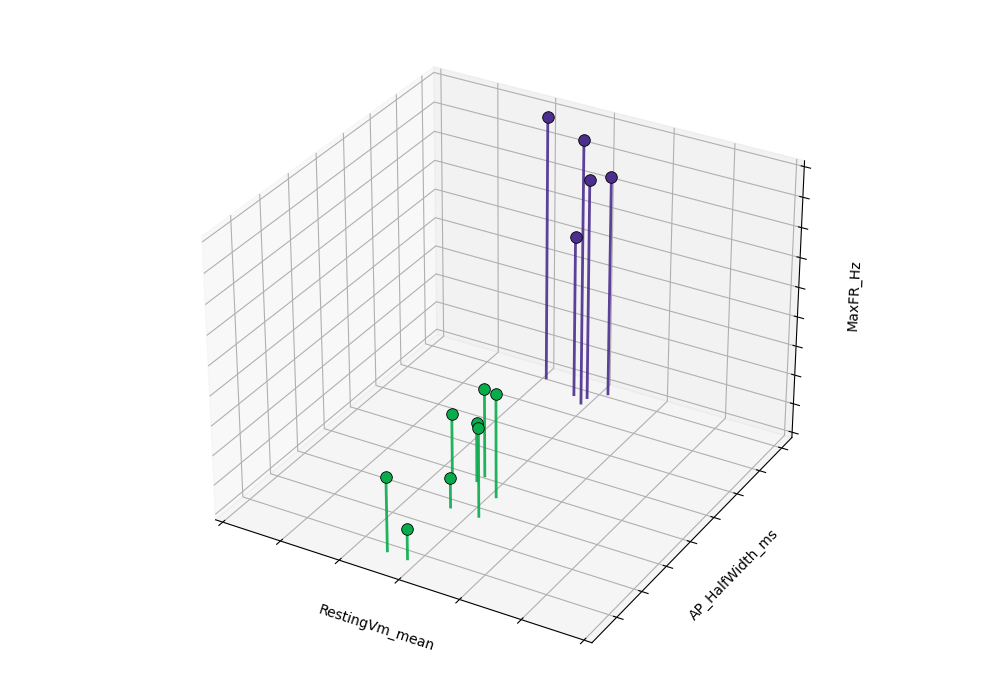

(<Figure size 1000x700 with 1 Axes>,
 <Axes3D: xlabel='RestingVm_mean', ylabel='AP_HalfWidth_ms', zlabel='MaxFR_Hz'>)

In [80]:
plot_cell_classification_3d(
    cell_summaries,
    output_prefix=figDataSaveDir + '/patching\cell_classification_3d',
    xlim=[-60,-120]
)